In [81]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


In [82]:
image_path = '/Users/arhaan/Documents/Codes/Image processing/hakla_kirk.png'

In [83]:
def load_and_prep(image_path):
    raw_image = Image.open(image_path).convert("RGB")

    prep_image = transforms.ToTensor()(raw_image)

    batched_tensor = prep_image.unsqueeze(0)

    return batched_tensor, raw_image


In [84]:
import torch.nn.functional as F
def padding(batched_tensor):

    pad_config = (2,2,2,2)

    pad_tensor = F.pad(batched_tensor,pad_config,mode='replicate')

    return pad_tensor

In [85]:
input_tensor , original_PIL = load_and_prep(image_path)
padded_tensor = padding(input_tensor)

print(f"Original image shape is: {input_tensor.shape}")
print(f"original image size : {original_PIL.size}")
print(f"Padded tensor is : {padded_tensor.shape}")



Original image shape is: torch.Size([1, 3, 248, 248])
original image size : (248, 248)
Padded tensor is : torch.Size([1, 3, 252, 252])


In [86]:
old_h = input_tensor.shape[2]
old_w = input_tensor.shape[3]

new_h = 500
new_w = 500

ratio_h = old_h/new_h
ratio_w = old_w/new_w


In [87]:
new_image = torch.zeros((1,3,new_h,new_h))

In [88]:
def weight(x,a=-0.5):

    x = abs(x) #distanc ehai toh no need to keep it less than 0..

    if(x<=1):
        ans = (a+2)*(x ** 3) - (a+3)*(x ** 2) + 1

    elif(x>1 and x<2):
        ans = (a)*(x ** 3) - (5*a)*(x ** 2) + (8*a)*(x) - 4*a

    else:        
        ans = 0


    return ans    

In [89]:
def bicubic(tensor):

    for y_out in range(new_h):
        for x_out in range(new_w):

            src_add_x = x_out*ratio_w
            src_add_y = y_out*ratio_h


            x_l = int(src_add_x)
            x_r = x_l + 1
            x_fl = x_l -1
            x_fr = x_l + 2

            y_t = int(src_add_y)
            y_b = y_t + 1
            y_ft = y_t - 1
            y_fb = y_t + 2

            #since for the r value of a line, the value of y remains constant

            #for y_t
            R_t = tensor[:,:,y_t,x_l]*weight(x_l-src_add_x) 
            + tensor[:,:,y_t,x_fl]*weight(x_fl-src_add_x) 
            + tensor[:,:,y_t,x_fr]*weight(x_fr-src_add_x) 
            + tensor[:,:,y_t,x_r]*weight(x_r-src_add_x)

            #for y_b
            R_b = tensor[:,:,y_b,x_l]*weight(x_l-src_add_x) 
            + tensor[:,:,y_b,x_fl]*weight(x_fl-src_add_x) 
            + tensor[:,:,y_b,x_fr]*weight(x_fr-src_add_x) 
            + tensor[:,:,y_b,x_r]*weight(x_r-src_add_x) 

            #for y_ft
            R_ft = tensor[:,:,y_ft,x_l]*weight(x_l-src_add_x) 
            + tensor[:,:,y_ft,x_fl]*weight(x_fl-src_add_x) 
            + tensor[:,:,y_ft,x_fr]*weight(x_fr-src_add_x) 
            + tensor[:,:,y_ft,x_r]*weight(x_r-src_add_x)

            #for y_fb
            R_fb = tensor[:,:,y_fb,x_l]*weight(x_l-src_add_x) 
            + tensor[:,:,y_fb,x_fl]*weight(x_fl-src_add_x) 
            + tensor[:,:,y_fb,x_fr]*weight(x_fr-src_add_x) 
            + tensor[:,:,y_fb,x_r]*weight(x_r-src_add_x)

            final_pixel = R_b*weight(y_b-src_add_y) + R_fb*weight(y_fb-src_add_y) + R_t*weight(y_t-src_add_y) + R_ft*weight(y_ft-src_add_y)


            new_image[:,:,y_out,x_out] = final_pixel


    return new_image        

In [90]:
def visualize_result(tensor_image):
    # 1. Clean up the data
    # Clone it so we don't mess up the original calculation
    #image_to_show = tensor_image.clone().detach().cpu()
    
    # 2. Remove the batch dimension (The '1')
    # Shape: [1, 3, H, W] -> [3, H, W]
    image_to_show = tensor_image.squeeze(0)
    
    # 3. Swap dimensions for Matplotlib
    # Shape: [3, H, W] -> [H, W, 3] (Channels Last)
    image_to_show = image_to_show.permute(1, 2, 0)
    
    # 4. Render
    plt.figure(figsize=(3, 3))
    plt.imshow(image_to_show)
    plt.axis('off') # Hide the ugly axis numbers
    plt.title("Bilinear")
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00070819847..0.9909577].


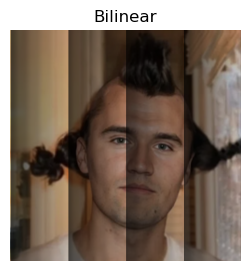

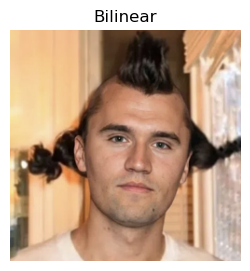

FInal shape : torch.Size([1, 3, 500, 500])


In [91]:
final_output = bicubic(padded_tensor)

visualize_result(final_output)
visualize_result(input_tensor)

print(f"FInal shape : {final_output.shape}")